In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
abdallahwagih_mall_customers_segmentation_path = kagglehub.dataset_download('abdallahwagih/mall-customers-segmentation')

print('Data source import complete.')


100%|██████████| 1.56k/1.56k [00:00<00:00, 2.93MB/s]

Extracting files...
Data source import complete.


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
import os

# Load dataset
df = pd.read_csv(os.path.join(abdallahwagih_mall_customers_segmentation_path, 'Mall_Customers.csv'))

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df1=df.copy()

In [5]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].copy()
X1 = df1[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].copy()

In [6]:
X1['Spending_Efficiency'] = X1['Spending Score (1-100)'] / X1['Annual Income (k$)']

In [7]:
X1 = X1.drop(['Spending Score (1-100)', 'Annual Income (k$)'], axis=1)

In [8]:
print(X)

     Age  Annual Income (k$)  Spending Score (1-100)
0     19                  15                      39
1     21                  15                      81
2     20                  16                       6
3     23                  16                      77
4     31                  17                      40
..   ...                 ...                     ...
195   35                 120                      79
196   45                 126                      28
197   32                 126                      74
198   32                 137                      18
199   30                 137                      83

[200 rows x 3 columns]


In [9]:
print(X1)

     Age  Spending_Efficiency
0     19             2.600000
1     21             5.400000
2     20             0.375000
3     23             4.812500
4     31             2.352941
..   ...                  ...
195   35             0.658333
196   45             0.222222
197   32             0.587302
198   32             0.131387
199   30             0.605839

[200 rows x 2 columns]


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sil_scores = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

In [12]:
for k, score in zip(K_range, sil_scores):
    print(f"K={k}, Silhouette Score={score:.3f}")

K=2, Silhouette Score=0.335
K=3, Silhouette Score=0.358
K=4, Silhouette Score=0.404
K=5, Silhouette Score=0.408
K=6, Silhouette Score=0.431
K=7, Silhouette Score=0.410
K=8, Silhouette Score=0.367
K=9, Silhouette Score=0.374


In [13]:
kmeans = KMeans(n_clusters=6, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [14]:
cluster_profile = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
cluster_profile

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,55.275862,47.620690,41.706897
1,32.875000,86.100000,81.525000
2,25.769231,26.115385,74.846154
3,26.733333,54.311111,40.911111
4,44.387097,89.774194,18.483871


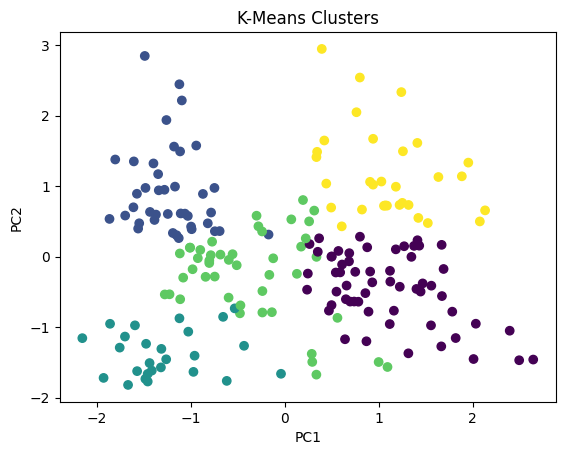

In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

import matplotlib.pyplot as plt

plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Cluster'])
plt.title("K-Means Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [16]:
X1_scaled = scaler.fit_transform(X1)

In [28]:
sil_scores1 = []

for k in K_range:
    k1means = KMeans(n_clusters=k, random_state=42)
    labels1 = k1means.fit_predict(X1_scaled)
    sil_scores1.append(silhouette_score(X1_scaled, labels1))

In [29]:
for k, score in zip(K_range, sil_scores1):
    print(f"K={k}, Silhouette Score={score:.3f}")

K=2, Silhouette Score=0.420
K=3, Silhouette Score=0.502
K=4, Silhouette Score=0.409
K=5, Silhouette Score=0.427
K=6, Silhouette Score=0.385
K=7, Silhouette Score=0.403
K=8, Silhouette Score=0.449
K=9, Silhouette Score=0.435


In [30]:
k1means = KMeans(n_clusters=3, random_state=42)
df1['Cluster'] = k1means.fit_predict(X1_scaled)

In [31]:
cluster_profil1 = df1.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
cluster_profil1

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,54.039474,57.486842,36.184211
1,30.442308,70.028846,55.182692
2,24.850000,23.000000,77.550000


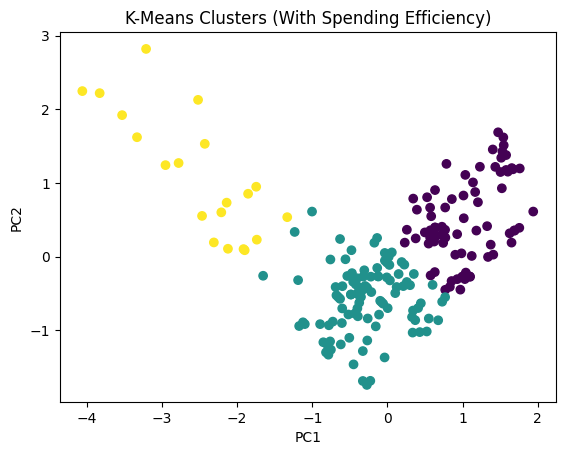

In [32]:
X1_pca = pca.fit_transform(X1_scaled)

plt.scatter(X1_pca[:,0], X1_pca[:,1], c=df1['Cluster'])
plt.title("K-Means Clusters (With Spending Efficiency)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [36]:
score_A = silhouette_score(X_scaled, kmeans.labels_)
score_B = silhouette_score(X1_scaled, k1means.labels_)

if score_B > score_A:
    print("\nModel B (with Spending Efficiency) shows a better silhouette score, indicating better-defined clusters.")
elif score_A > score_B:
    print("\nModel A (with Original Features) shows a better silhouette score, indicating better-defined clusters.")
else:
    print("\nBoth models have similar silhouette scores.")


Model B (with Spending Efficiency) shows a better silhouette score, indicating better-defined clusters.


In [37]:
print(f"Model A (Original Features, K=6): Silhouette Score = {score_A:.3f}")
print(f"Model B (With Spending Efficiency, K=3): Silhouette Score = {score_B:.3f}")

Model A (Original Features, K=6): Silhouette Score = 0.188
Model B (With Spending Efficiency, K=3): Silhouette Score = 0.502
